<a href="https://colab.research.google.com/github/AkshitThakur/_mini_python_projects/blob/main/Customer_Spending_Behavior_Analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers_data = {
    "customer_id" : [101, 102, 103, 104, 105],
    "customer_name" : ["John", "Jane", "Bob", "Alice", "Tom"],
    "age" : [29, 35, 42, 28, 32],
    "city" : ["New York", "Paris", "London", "Tokyo", "Sydney"]
}
customers_df = pd.DataFrame(customers_data)
customers_df

,customer_id,customer_name,age,city
0,101,John,29,New York
1,102,Jane,35,Paris
2,103,Bob,42,London
3,104,Alice,28,Tokyo
4,105,Tom,32,Sydney


In [3]:
transcations_data = {
    "transaction_id" : range(1, 11),
    "customer_id" :  [101, 102, 103, 104, 105, 101, 102, 103, 104, 105],
    "merchant_id": [201, 202, 203, 204, 201, 202, 203, 204, 201, 202],
    "amount": [150, 200, 80, 120, 250, 300, 220, 100, 130, 180],
    "category": ["Electronics", "Grocery", "Dining", "Fashion", "Electronics", "Fashion", "Dining", "Grocery", "Dining", "Electronics"],
    "transaction_date": pd.to_datetime(["2024-01-10", "2024-01-12", "2024-01-14", "2024-01-15", "2024-01-18", "2024-02-05", "2024-02-07", "2024-02-10", "2024-02-14", "2024-02-18"])
}
transactions_df = pd.DataFrame(transcations_data)
transactions_df

,transaction_id,customer_id,merchant_id,amount,category,transaction_date
0,1,101,201,150,Electronics,2024-01-10
1,2,102,202,200,Grocery,2024-01-12
2,3,103,203,80,Dining,2024-01-14
3,4,104,204,120,Fashion,2024-01-15
4,5,105,201,250,Electronics,2024-01-18
5,6,101,202,300,Fashion,2024-02-05
6,7,102,203,220,Dining,2024-02-07
7,8,103,204,100,Grocery,2024-02-10
8,9,104,201,130,Dining,2024-02-14
9,10,105,202,180,Electronics,2024-02-18


In [4]:
merchants_data = {
    "merchant_id": [201, 202, 203, 204],
    "merchant_name": ["Best Buy", "Whole Foods", "McDonald's", "Zara"],
    "merchant_category": ["Electronics", "Grocery", "Dining", "Fashion"]
}
merchants_df = pd.DataFrame(merchants_data)
merchants_df

,merchant_id,merchant_name,merchant_category
0,201,Best Buy,Electronics
1,202,Whole Foods,Grocery
2,203,McDonald's,Dining
3,204,Zara,Fashion


/tmp/ipykernel_2554/142499806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="category", y="amount", data = category_spending, palette="viridis")


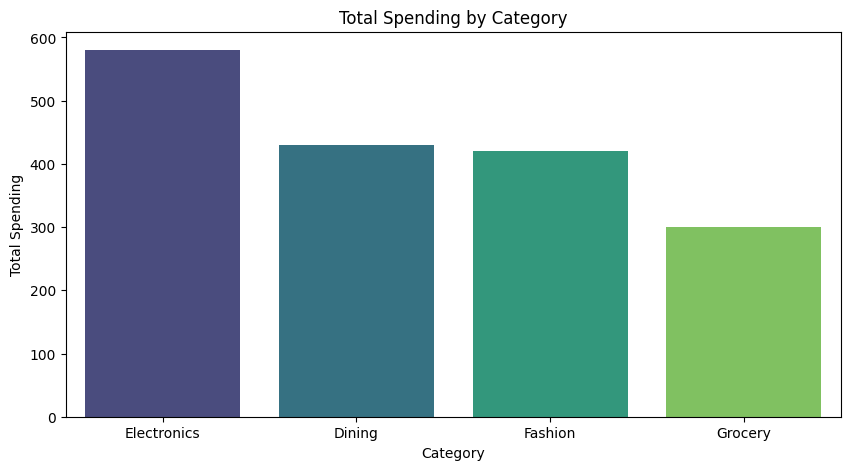

In [11]:
category_spending = transactions_df.groupby("category")["amount"].sum().reset_index()
category_spending = category_spending.sort_values("amount", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x="category", y="amount", data = category_spending, palette="viridis")
plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Spending")
plt.show()


/tmp/ipykernel_2554/3852664231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="customer_name", x="total_spending", data=customer_spending, palette="viridis")


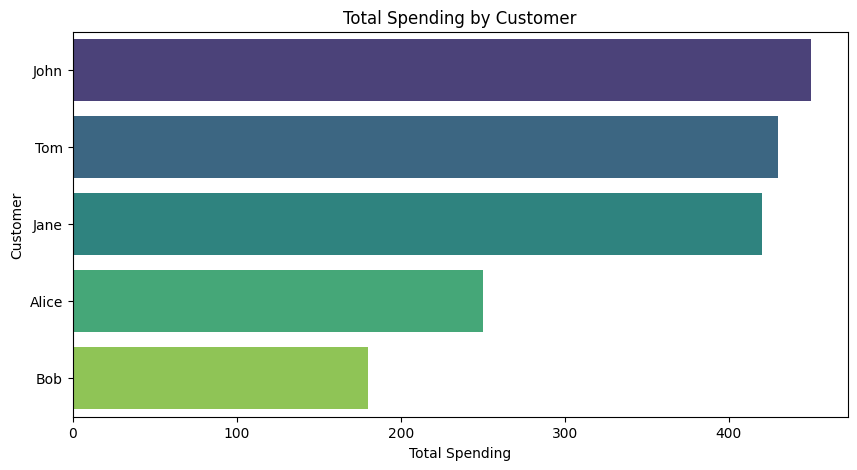

In [26]:
customer_spending = transactions_df.groupby("customer_id")["amount"].agg(["sum", "mean"]).reset_index()
customer_spending.columns = ["customer_id", "total_spending", "average_spending"]
customer_spending = pd.merge(customer_spending, customers_df.loc[:, ["customer_id", "customer_name"]], on="customer_id")
customer_spending = customer_spending.sort_values("total_spending", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(y="customer_name", x="total_spending", data=customer_spending, palette="viridis")
plt.title("Total Spending by Customer")
plt.ylabel("Customer")
plt.xlabel("Total Spending")
plt.show()

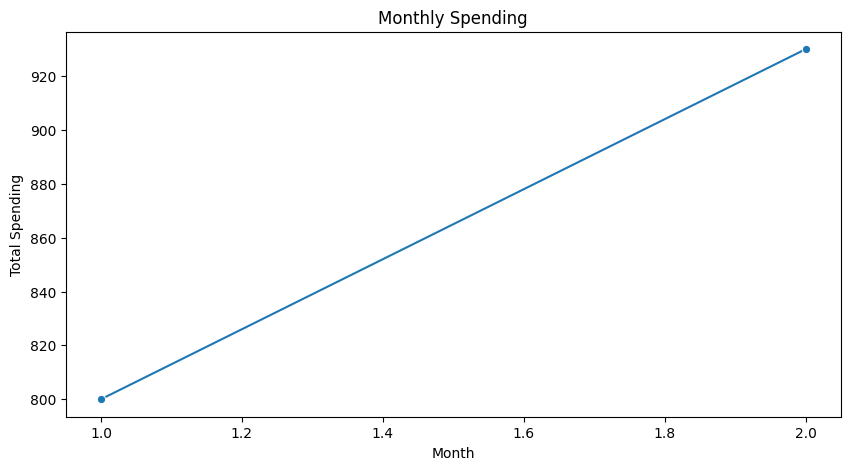

In [32]:
transactions_df["month"] = transactions_df["transaction_date"].dt.month
monthly_spending = transactions_df.groupby("month")["amount"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x="month", y="amount", data=monthly_spending, marker="o")
plt.title("Monthly Spending")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.show()